# Churn Prediction Pipeline

**Single entry point for binary and multiclass churn prediction.**

### How to use
1. Open `src/config.py`
2. Set `MODE = ClassificationType.BINARY` or `ClassificationType.MULTICLASS`
3. Set `MODEL = "random_forest"` or `"xgboost"`
4. Set `PRE_PROCESSING_FLAG = True (default) or False` to control whether to re-run the pre-processing step (if False, it will skip if the output file already exists).
5. Run all cells — everything else resolves automatically from config.

# Churn Prediction

**List of Pipeline Steps:**
1. **Load and Prepare Data** - 
    - Set up the target variable for binary classification.
    - Drop irrelevant features. 
2. **Data Splitting** - 
    - Data splitting into Train(70%), Validation(15%), and Test(15%).
    - Split using GroupShuffleSplit to ensure all snapshots of a customer are in the same set.
3. **Model Tuning and Selection** -  
    - Use PredefinedSplit for GridSearchCV. 
    - Hyperparameter tuning and model selection based on validation performance.
4. **Evaluation on the Test set** - 
    - Confusion Matrix, Classification Metrics, ROC CURVE
    - Feature Importance Analysis - Analyze feature importance from the best model to identify key drivers of churn

**Assumptions:**
- The data is clean
- No missing values
- EDA and feature engineering have been done

**Random Forest Model (Tree-based ensemble) is used as the Baseline model because**
- Interally handles feature selection and importance
- Robust to outliers and noise

**Tree-Based Ensemble models are used because:**

- Implicitly perform feature selection — explicit feature selection is not required.
- Robust to noise and outliers.
- No feature scaling required.

**Random Forest is chosen as the baseline model over XGBoost because:**

- Random Forest is based on bagging — each tree is trained on a different random bootstrap sample of the data, and trees are trained in parallel.
- XGBoost is based on boosting — models are trained sequentially, where each new model focuses on correcting the errors made by the previous one.
- **Robustness** : Random Forest is more robust than XGBoost overall.
- **Overfitting** : RF reduces variance and prevents overfitting because it averages many uncorrelated trees, each built on a random subset of features. 
- XGBoost is prone to overfitting without careful regularisation and early stopping.
- **Hyperparameter Sensitivity** : XGBoost requires more careful hyperparameter tuning compared to Random Forest, as it is more sensitive to parameters like learning rate, tree depth, and subsampling.
- **Outlier Robustness** : Random Forest is more robust to outliers than XGBoost, as boosting can amplify outliers — each tree focuses on residual errors, which may cause the model to overfit to noisy data points.

# MLflow Tracking
**MLflow Tracking is used to log and compare model performance across different runs.**
- Log hyperparameters, metrics, and artifacts (like feature importance plots) for each run.
- Compare different models and hyperparameter configurations to identify the best performing model based on validation metrics.
- Use MLflow's UI to visualize and analyze the results of different runs. In the MLflow UI, you can view and compare different runs, analyze metrics, and visualize artifacts like feature importance plots.
- Ensure reproducibility by logging all relevant information for each run, allowing for easy replication of results in the future.

# How to run mldflow ui - locally
1. Open terminal and navigate to the project directory.
2. Run the command: `python -m mlflow ui`
3. Open a web browser and go to `http://localhost:5000` to access the MLflow UI.




## 0. Imports & Config

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import src.config as cfg
from src.config import ClassificationType

import mlflow

from src.mlflow_logger import (
    init_mlflow,
    make_run_name,
    start_run,
    enable_mlflow_autolog,
    log_mlflow_run_config,
    log_mlflow_evaluation,
    # log_mlflow_model_artifact, # obsolete — use log_mlflow_sklearn_model instead
    log_mlflow_sklearn_model,
    log_mlflow_feature_importance,
    register_model,
    tag_gridsearch_child_runs,
    upload_pipeline_log_file
)

from src.pipeline_logger import get_logger, get_null_logger




In [2]:
# Initialize MLflow and get logger
init_mlflow()
logger, log_path = get_logger(mode=cfg.MODE.value, model=cfg.MODEL)

if logger is None:
    logger = get_null_logger()

MLflow tracking URI : mlruns
MLflow experiment   : churn-prediction
2026-03-21 17:16:43 | INFO  | Logger initialised — mode=binary  model=random_forest
2026-03-21 17:16:43 | INFO  | Log file: logs\pipeline_binary_random_forest_20260321_171643.log


In [3]:
# Display configuration settings
print(f'Mode    : {cfg.MODE.value}')
print(f'Model   : {cfg.MODEL}')

# Print scoring and target values of selected classification type
mode_config = cfg.MODE_CONFIGS[cfg.MODE]
print(f'Target  : {mode_config["target_col"]}')
print(f'Scoring : {mode_config["scoring"]}')


Mode    : binary
Model   : random_forest
Target  : outcome_binary
Scoring : roc_auc


## 1. Preprocess Raw Data

In [ ]:
import src.preprocessor
# ── Skip condition ────────────────────────────────────────────────────────────
# Skip if raw_churndata.csv already exists and PRE_PROCESSING_FLAG=False
out_path = cfg.INPUT_PATH
source_path = cfg.SOURCE_DATA_PATH

# Only skip when using default source path
using_default_source = source_path == cfg.SOURCE_DATA_PATH

if out_path.exists() and using_default_source:
    # Log preprocessing value of conditional parameters i.e. source_path
    logger.info(f"[PROCESSING]Source path: {source_path}")
    logger.info(f"[PROCESSING]Preprocessing skipped. Output file already exists: {out_path}")
else:
    # Steps: Start preprocessing
    #    1. Load source data
    #    2. Validate required source columns
    #    3. Create binary target column
    #    4. Apply missing value imputation
    #    5. Save to out_path
    
    src.preprocessor.preprocess_raw_data(source_path, out_path, logger=logger)

    #####
    # # Step 1: Load source data
    # source_churndata = src.preprocessor.load_source_data(source_path)
    
    # # Step 2: Validate required columns exist
    # src.preprocessor.validate_source_columns(source_churndata)
    
    # # Step 3: Create binary target column
    # raw_churndata = src.preprocessor.create_binary_target(source_churndata)
    
    # # Step 4: Apply missing value imputation
    # raw_churndata = src.preprocessor.apply_missing_value_imputation(raw_churndata, cfg.FILLNA_COLS)
    
    # # Step 5: Save preprocessed data
    # src.preprocessor.save_preprocessed_data(raw_churndata, out_path)

2026-03-21 17:16:43 | INFO  | [preprocessor] Starting preprocessing: data\trajectory_snapshots.csv → data\raw_churndata.csv
2026-03-21 17:16:43 | INFO  | [preprocessor] Loading source data: data\trajectory_snapshots.csv
2026-03-21 17:16:43 | INFO  | [preprocessor] Source data loaded — shape=(24697, 65)
2026-03-21 17:16:43 | INFO  | [preprocessor] Validating source columns — looking for 'outcome'
2026-03-21 17:16:43 | INFO  | [preprocessor] Source column validation passed.
2026-03-21 17:16:43 | INFO  | [preprocessor] Creating binary target 'outcome_binary' — positive class='churn'
2026-03-21 17:16:43 | INFO  | [preprocessor] Binary target distribution: {'nonchurn': 23182, 'churn': 1515}
2026-03-21 17:16:43 | INFO  | [preprocessor] Applying missing value imputation — columns: ['days_since_renewal_discussion_started']
2026-03-21 17:16:43 | INFO  | [preprocessor] 'days_since_renewal_discussion_started': filled 7849 missing values with -1
2026-03-21 17:16:43 | INFO  | [preprocessor] Preproc

# BINARY CLASSIFICATION

## 2. Load Data

In [5]:
from src.data_loader import load_data

# Load preprocessed data for modeling
X_b_rf, y_b_rf, cat_features = load_data(input_path=cfg.INPUT_PATH,logger=logger)

2026-03-21 17:16:43 | INFO  | [data_loader] Loading data from: data\raw_churndata.csv
2026-03-21 17:16:43 | INFO  | [data_loader] Mode: binary  |  Model: random_forest
2026-03-21 17:16:43 | INFO  | [data_loader] Raw file loaded — shape: (24697, 66)
2026-03-21 17:16:43 | INFO  | [data_loader] Required columns present: ['deal_id', 'company_id', 'outcome_binary']
2026-03-21 17:16:43 | INFO  | [data_loader] Dropped 9 columns: ['snapshot_date', 'renewal_stage', 'renewal_discussions_started', 'days_since_renewal_discussion_started', 'final_arr', 'industry', 'region', 'forecast_amount', 'outcome']
2026-03-21 17:16:43 | INFO  | [data_loader] Categorical features: 9  → ['support_ticket_trend_30d', 'stakeholder_engagement_trend', 'response_time_trend', 'engagement_trend_90d', 'nps_trend_90d', 'adoption_trend_90d', 'sentiment_trend', 'company_size', 'deal_owner']
2026-03-21 17:16:43 | INFO  | [data_loader] Target distribution :
outcome_binary
nonchurn    23182
churn        1515
2026-03-21 17:16:4

In [6]:
# Optional: Load raw_churndata to inspect preprocessing results
# raw_churndata = pd.read_csv(cfg.INPUT_PATH)
# print(f'Columns in raw_churndata but not in X: {set(raw_churndata.columns) - set(X.columns)}')

## 3. Split Data

In [7]:
from src.splitter import split_data, verify_split, summarise_target_distribution
# Split data into train/val/test sets
X_train_b_rf, X_val_b_rf, X_test_b_rf, y_train_b_rf, y_val_b_rf, y_test_b_rf = split_data(X_b_rf,
                                                                                           y_b_rf, 
                                                                                           cfg.KEY_ID_COLS, 
                                                                                           logger=logger)

2026-03-21 17:16:43 | INFO  | [splitter] Starting GroupShuffleSplit — total rows: 24697
2026-03-21 17:16:43 | INFO  | [splitter] Split config — train=70%  val=15%  test=15%  random_state=42


In [8]:
# Verify the data split is correct (no leakage, correct sizes)
verify_split(X_train_b_rf, 
             X_val_b_rf, 
             X_test_b_rf, 
             logger=logger)

2026-03-21 17:16:43 | INFO  | [Verifying split] — checking for customer leakage across sets
2026-03-21 17:16:43 | INFO  | Customer counts per set:
2026-03-21 17:16:43 | INFO  |   Train : 350
2026-03-21 17:16:43 | INFO  |   Val   : 75
2026-03-21 17:16:43 | INFO  |   Test  : 75
2026-03-21 17:16:43 | INFO  | Overlap check:
2026-03-21 17:16:43 | INFO  |   Train ∩ Val  : 0 customers
2026-03-21 17:16:43 | INFO  |   Train ∩ Test : 0 customers
2026-03-21 17:16:43 | INFO  |   Val   ∩ Test : 0 customers
2026-03-21 17:16:43 | INFO  |   No leakage detected ✓


In [9]:
# Summarise target distribution in each split to check for imbalance
dist_b_rf = summarise_target_distribution(y_train_b_rf, 
                                          y_val_b_rf, 
                                          y_test_b_rf,
                                          X_train_b_rf, 
                                          X_val_b_rf, X_test_b_rf)
display(dist_b_rf)

,nonchurn,churn
Set,,
Train,322 (92.0%),28 (8.0%)
Val,72 (96.0%),3 (4.0%)
Test,70 (93.33%),5 (6.67%)


In [10]:
# Drop KEY_ID_COLS after verification, before pipeline
X_train_b_rf = X_train_b_rf.drop(columns=cfg.KEY_ID_COLS)
X_val_b_rf   = X_val_b_rf.drop(columns=cfg.KEY_ID_COLS)
X_test_b_rf  = X_test_b_rf.drop(columns=cfg.KEY_ID_COLS)

# Log Drop of KEY_ID_COLS as non informative features for modeling
logger.info(f"Dropped Non Informative columns {cfg.KEY_ID_COLS} from training, validation, and test sets.")

2026-03-21 17:16:44 | INFO  | Dropped Non Informative columns ['deal_id', 'company_id'] from training, validation, and test sets.


## 4. Build Pipeline & Search Set

In [11]:
from src.pipeline_builder import build_pipeline, build_search_set

# Build the modeling pipeline and search set for hyperparameter tuning

# # Build the pipeline with categorical features for one-hot encoding 
pipeline_b_rf = build_pipeline(cat_features, 
                               logger=logger) 
# # Build the search set for hyperparameter tuning
X_search_b_rf, y_search_b_rf, pds_b_rf = build_search_set(X_train_b_rf, 
                                                          X_val_b_rf, 
                                                          y_train_b_rf, 
                                                          y_val_b_rf,
                                                          logger=logger) 

2026-03-21 17:16:44 | INFO  | [pipeline_builder] Building pipeline — model='random_forest'
2026-03-21 17:16:44 | INFO  | [pipeline_builder] Categorical features to encode (9): ['support_ticket_trend_30d', 'stakeholder_engagement_trend', 'response_time_trend', 'engagement_trend_90d', 'nps_trend_90d', 'adoption_trend_90d', 'sentiment_trend', 'company_size', 'deal_owner']
2026-03-21 17:16:44 | INFO  | [pipeline_builder] Pipeline built — steps: prepro → rf (RandomForestClassifier)
2026-03-21 17:16:44 | INFO  | [pipeline_builder] Building search set — train=17379  val=3609
2026-03-21 17:16:44 | INFO  | [pipeline_builder] Search set built -
2026-03-21 17:16:44 | INFO  |   Train rows =17379  Val rows =3609
2026-03-21 17:16:44 | INFO  |   Total =20988 CV folds =1
2026-03-21 17:16:44 | INFO  | [pipeline_builder] PredefinedSplit: -1=train rows  0=val rows


# 5-8. Model Tuning, Selection, Evaluation, and Feature Importance Analysis

2026-03-21 17:16:45 | INFO  | [mlflow_logger] Run name generated: random_forest_binary_v18_20260321
2026-03-21 17:16:45 | INFO  | [mlflow_logger] sklearn autologging enabled — log_models=False  max_tuning_runs=5
2026-03-21 17:16:45 | INFO  | [mlflow_logger] Run config logged to MLflow params: {'mode': 'binary', 'model': 'random_forest', 'train_size': 0.7, 'val_size': 0.15, 'random_state': 42, 'scoring': 'roc_auc', 'target_col': 'outcome_binary', 'input_path': 'data\\raw_churndata.csv'}
2026-03-21 17:16:46 | INFO  | [tuner] Starting GridSearchCV — model=random_forest  scoring=roc_auc
2026-03-21 17:16:46 | INFO  | [tuner] Hyperparameter grid: {'rf__n_estimators': [100, 200, 'not_an_int'], 'rf__max_depth': [10, 20], 'rf__min_samples_split': [2, 5, 10], 'rf__min_samples_leaf': [1, 2, 4], 'rf__max_features': ['sqrt', 'log2', 0.3, 0.5], 'rf__class_weight': ['balanced', 'balanced_subsample']}
2026-03-21 17:16:46 | INFO  | [tuner] Total combinations to evaluate: 432
Fitting 1 folds for each of

2026/03/21 17:22:00 INFO mlflow.sklearn.utils: Logging the 5 best runs, 427 runs will be omitted.


2026-03-21 17:22:01 | INFO  | [tuner] GridSearchCV complete.
2026-03-21 17:22:01 | INFO  | [tuner] Best score : 0.9995  (roc_auc)
2026-03-21 17:22:01 | INFO  | [tuner] Best params: {'rf__class_weight': 'balanced', 'rf__max_depth': 20, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 5, 'rf__n_estimators': 200}
MLflow: renamed 5 child runs  →  CVFold0_hyperparameterSet-000 ... CVFold0_hyperparameterSet-004
2026-03-21 17:22:04 | INFO  | [tuner] Extracting top-5 results from cv_results_
2026-03-21 17:22:04 | INFO  | [tuner] Top-5 results extracted.


,Mean Test ROC_AUC,Rank,rf__class_weight,rf__max_depth,rf__max_features,rf__min_samples_leaf,rf__min_samples_split,rf__n_estimators
0,0.9995,1,balanced,20,sqrt,2,5,200
1,0.9994,2,balanced,20,sqrt,2,5,100
2,0.9994,3,balanced_subsample,20,sqrt,2,10,100
3,0.9994,4,balanced_subsample,20,log2,2,2,200
4,0.9994,5,balanced,20,log2,2,2,200


2026-03-21 17:22:04 | INFO  | [evaluation] Starting evaluation — mode=binary  test_rows=3709


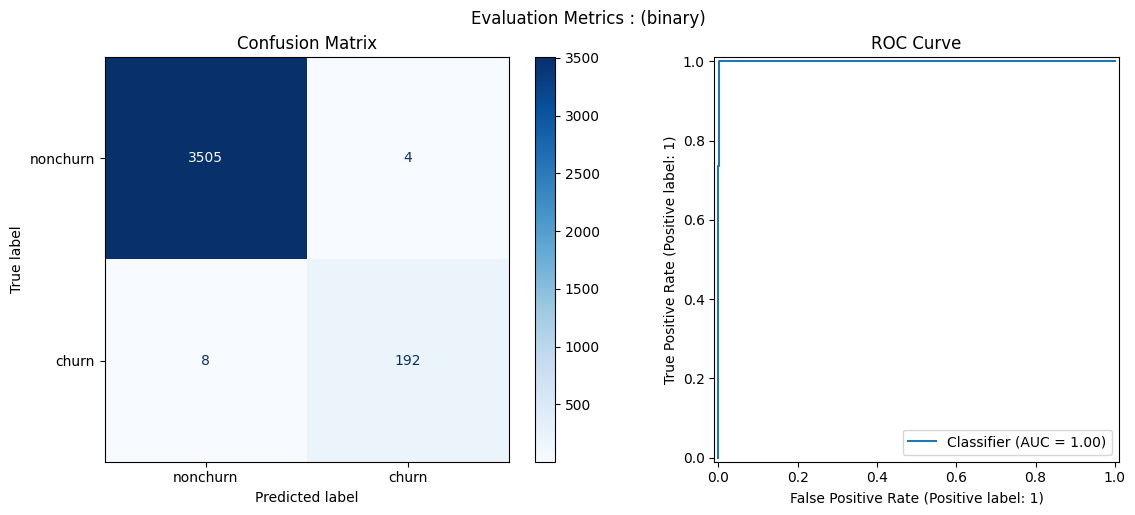

2026-03-21 17:22:05 | INFO  | [mlflow_logger] Logged metric — test_roc_auc=0.9998
2026-03-21 17:22:05 | INFO  | [mlflow_logger] Logged artifact — classification_report.txt
2026-03-21 17:22:05 | INFO  | [mlflow_logger] Logged artifact — evaluation_plots.png
MLflow: evaluation metrics and artifacts logged.
2026-03-21 17:22:05 | INFO  | [mlflow_logger] MLflow: evaluation metrics and artifacts logged.
2026-03-21 17:22:05 | INFO  | [feature_importance] Extracting feature importances — top_n=5
2026-03-21 17:22:05 | INFO  | [feature_importance] Total features after encoding: 77
2026-03-21 17:22:05 | INFO  | [feature_importance] Top-5 most influential features:
                        Feature  Importance
      executive_logins_last_30d      0.1283
unique_users_logged_in_last_30d      0.1114
         features_used_last_30d      0.1002
         avg_sentiment_last_30d      0.0806
           total_logins_last_7d      0.0695


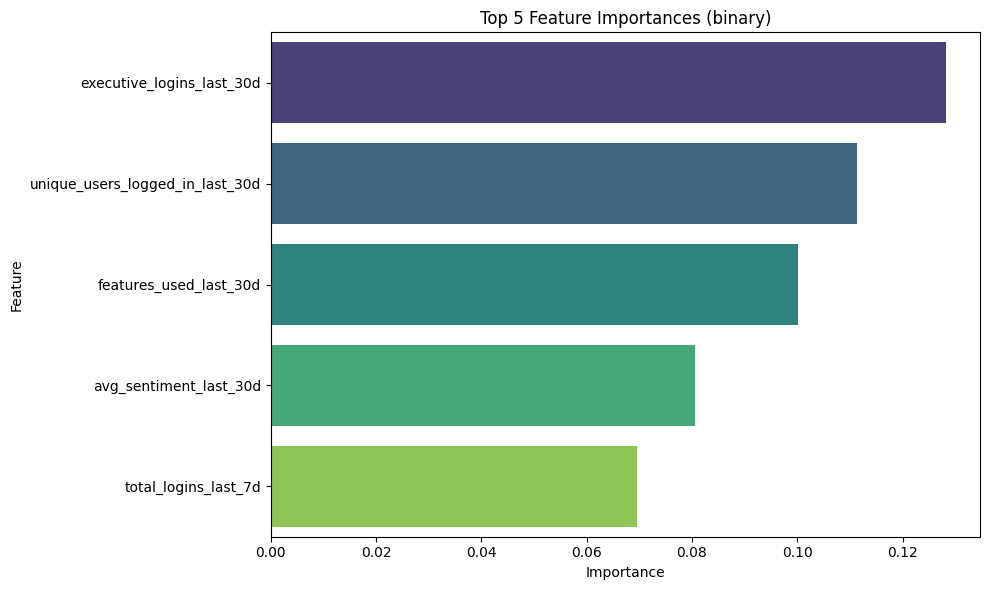

2026-03-21 17:22:05 | INFO  | [feature_importance] Feature importance extraction complete.
2026-03-21 17:22:05 | INFO  | [mlflow_logger] Logged artifact — feature_importance.json
2026-03-21 17:22:06 | INFO  | [mlflow_logger] Logged artifact — feature_importance.png
MLflow: feature importance logged.
2026-03-21 17:22:06 | INFO  | [mlflow_logger] MLflow: feature importance logged.
2026-03-21 17:22:06 | INFO  | [model_saver] Saving model — mode=binary  model=random_forest  versioned=True
2026-03-21 17:22:06 | INFO  | [model_saver] Model saved: model\random_forest_binary_20260321_172206.pkl
2026-03-21 17:22:06 | INFO  | [model_saver] Metadata saved: model\random_forest_binary_20260321_172206.json
2026-03-21 17:22:06 | INFO  | [model_saver] Best params: {'rf__class_weight': 'balanced', 'rf__max_depth': 20, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 5, 'rf__n_estimators': 200}
2026-03-21 17:22:06 | INFO  | [model_saver] Score (roc_auc): 0.9998446850954688

2026/03/21 17:22:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/21 17:22:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow: logged sklearn model → models:/m-ff9c7aa594354e488209dbb6fa056a44
        Artifacts: model.pkl, conda.yaml, requirements.txt, python_env.yaml
2026-03-21 17:22:11 | INFO  | [mlflow_logger] MLflow: logged sklearn model → models:/m-ff9c7aa594354e488209dbb6fa056a44
2026-03-21 17:22:11 | INFO  | [mlflow_logger] Artifacts: model.pkl, conda.yaml, requirements.txt, python_env.yaml
2026-03-21 17:22:11 | INFO  | Pipeline complete. Model saved to: model\random_forest_binary_20260321_172206.pkl
2026-03-21 17:22:11 | INFO  | [mlflow_logger] Registering model — registry='churn_binary_random_forest'  run_id=c2e69055ba884458bcb12214a418e594  uri=runs:/c2e69055ba884458bcb12214a418e594/sklearn_model
MLflow: registered  'churn_binary_random_forest'  version 12
        run         : random_forest_binary_v18_20260321
        run_id      : c2e69055ba884458bcb12214a418e594
        stage       : None  — promote manually when ready
2026-03-21 17:22:11 | INFO  | [mlflow_logger] MLflow: registered  'chur

In [12]:
# ── MLflow run: Binary ────────────────────────────────────────────────────────

run_name = make_run_name(cfg.MODEL, cfg.MODE.value, logger=logger)
 
with start_run(run_name=run_name):
    try:
        enable_mlflow_autolog(logger=logger)
        log_mlflow_run_config(logger=logger)

        # Log training and test sets as MLflow inputs (as pandas DataFrames)
        mlflow.log_input(
            mlflow.data.from_pandas(X_train_b_rf, 
                             source=str(cfg.INPUT_PATH), 
                             name="train"), 
                context="train")
        mlflow.log_input(
            mlflow.data.from_pandas(X_test_b_rf,  
                             source=str(cfg.INPUT_PATH), 
                             name="test"),  
                context="test")
        
 
        # Step 5: Hyperparameter Tuning
        from src.tuner import run_grid_search, get_top_results
        grid_search_b_rf = run_grid_search(
            pipeline_b_rf, X_search_b_rf, y_search_b_rf, pds_b_rf,
            logger=logger,
        )
        # After GridSearchCV.fit(), rename + tag autolog child runs for better traceability in MLflow UI
        tag_gridsearch_child_runs(mlflow.active_run().info.run_id)
 
        top_results_b_rf = get_top_results(grid_search_b_rf, n=5, logger=logger)
        display(top_results_b_rf)
 
        # Step 6: Evaluate on Test Set
        from src.evaluation import evaluate
        metrics_b_rf = evaluate(grid_search_b_rf, X_test_b_rf, y_test_b_rf, logger=logger)
        log_mlflow_evaluation(metrics_b_rf, logger=logger)
 
        # Step 7: Feature Importance
        from src.feature_importance import get_feature_importance
        feat_imp_df_b_rf, feat_imp_fig_b_rf = get_feature_importance(
            grid_search_b_rf, top_n=5, logger=logger,
        )
        log_mlflow_feature_importance(feat_imp_df_b_rf, feat_imp_fig_b_rf, logger=logger)
 
        # Step 8: Save Model (joblib) + log as MLflow artifact + register in Model Registry
        from src.model_saver import save_model
        model_path_b_rf = save_model(grid_search_b_rf, metrics_b_rf, logger=logger)
        # Log MLflow Artifact 
        # Log the model using MLflow's sklearn integration, which includes environment files and model signature automatically
        log_mlflow_sklearn_model(grid_search_b_rf, X_test_b_rf[:5], logger=logger)
 
        logger.info(f"Pipeline complete. Model saved to: {model_path_b_rf}")
        register_model(cfg.MODEL, cfg.MODE.value, logger=logger)
 
        current_run = mlflow.active_run()
        logger.info(
            f"Registered model info — Run ID: {current_run.info.run_id}, "
            f"Run Name: {current_run.info.run_name}, "
            f"Experiment ID: {current_run.info.experiment_id}"
        )
 
    except Exception as e:
        # Write exception to the .log file so the artifact has the full error
        logger.error(f"[pipeline] Run FAILED — {type(e).__name__}: {e}")
        # Tag the run in MLflow UI — visible in the run list without opening the run
        mlflow.set_tag("run_status",        "FAILED")
        mlflow.set_tag("failure_exception", type(e).__name__)
        mlflow.set_tag("failure_message",   str(e)[:250])   # MLflow tag char limit
        raise   # re-raise → script exits with non-zero code
 
    finally:
        # Always runs — whether try succeeded, except was triggered, or raise fired.
        # The .log file is flushed to disk before this point because Python's
        # logging FileHandler writes synchronously on every log.info/error call.
        upload_pipeline_log_file(log_path, logger=logger)

# MULTICLASS CLASSIFICATION

In [ ]:
# Set Mode and Model
cfg.MODE = ClassificationType.MULTICLASS

# Initialize MLflow and get logger
init_mlflow()
logger, log_path = get_logger(mode=cfg.MODE.value, model=cfg.MODEL)

if logger is None:
    logger = get_null_logger()

## 2. Load Data

In [ ]:
from src.data_loader import load_data

# Load preprocessed data for modeling
X_m_rf, y_m_rf, cat_features = load_data(input_path=cfg.INPUT_PATH
                                         ,logger=logger)

## 3. Split Data

In [ ]:
from src.splitter import split_data, verify_split, summarise_target_distribution
# Split data into train/val/test sets
X_train_m_rf, X_val_m_rf, X_test_m_rf, y_train_m_rf, y_val_m_rf, y_test_m_rf = split_data(X_m_rf, y_m_rf, 
                                                                                          cfg.KEY_ID_COLS,
                                                                                          logger=logger)

In [ ]:
# Verify the data split is correct (no leakage, correct sizes)
verify_split(X_train_m_rf, 
             X_val_m_rf, 
             X_test_m_rf, 
             logger=logger)

In [ ]:
# Summarise target distribution in each split to check for imbalance
dist_m_rf = summarise_target_distribution(y_train_m_rf,
                                        y_val_m_rf, 
                                        y_test_m_rf, 
                                        X_train_m_rf, 
                                        X_val_m_rf, 
                                        X_test_m_rf,
                                        logger=logger
                                        )
display(dist_m_rf)

In [ ]:
# Drop KEY_ID_COLS after verification, before pipeline
X_train_m_rf = X_train_m_rf.drop(columns=cfg.KEY_ID_COLS)
X_val_m_rf   = X_val_m_rf.drop(columns=cfg.KEY_ID_COLS)
X_test_m_rf  = X_test_m_rf.drop(columns=cfg.KEY_ID_COLS)

# Log Drop of KEY_ID_COLS as non informative features for modeling
logger.info(f"Dropped Non Informative columns {cfg.KEY_ID_COLS} from training, validation, and test sets.")

## 4. Build Pipeline & Search Set

In [ ]:
from src.pipeline_builder import build_pipeline, build_search_set

# Build the modeling pipeline and search set for hyperparameter tuning

# # Build the pipeline with categorical features for one-hot encoding 
pipeline_m_rf = build_pipeline(cat_features
                               ,logger=logger) 
# # Build the search set for hyperparameter tuning
X_search_m_rf, y_search_m_rf, pds_m_rf = build_search_set(X_train_m_rf, 
                                                          X_val_m_rf, 
                                                          y_train_m_rf, 
                                                          y_val_m_rf,
                                                          logger=logger)

## 5-8. Model Tuning, Selection, Evaluation, and Feature Importance Analysis

In [ ]:
# ── MLflow run: Multi-class ────────────────────────────────────────────────────────

run_name = make_run_name(cfg.MODEL, cfg.MODE.value, logger=logger)
 
with start_run(run_name=run_name):
    try:
        enable_mlflow_autolog(logger=logger)
        log_mlflow_run_config(logger=logger)

        # Log training and test sets as MLflow inputs (as pandas DataFrames)
        mlflow.log_input(
            mlflow.data.from_pandas(X_train_m_rf, 
                             source=str(cfg.INPUT_PATH), 
                             name="train"), 
                context="train")
        mlflow.log_input(
            mlflow.data.from_pandas(X_test_m_rf,  
                             source=str(cfg.INPUT_PATH), 
                             name="test"),  
                context="test")
 
        # Step 5: Hyperparameter Tuning
        from src.tuner import run_grid_search, get_top_results
        grid_search_m_rf = run_grid_search(
            pipeline_m_rf, X_search_m_rf, y_search_m_rf, pds_m_rf,
            logger=logger,
        )
        # After GridSearchCV.fit(), rename + tag autolog child runs for better traceability in MLflow UI
        tag_gridsearch_child_runs(mlflow.active_run().info.run_id)
 
        top_results_m_rf = get_top_results(grid_search_m_rf, n=5, logger=logger)
        display(top_results_m_rf)
 
        # Step 6: Evaluate on Test Set
        from src.evaluation import evaluate
        metrics_m_rf = evaluate(grid_search_m_rf, X_test_m_rf, y_test_m_rf, logger=logger)
        log_mlflow_evaluation(metrics_m_rf, logger=logger)
 
        # Step 7: Feature Importance
        from src.feature_importance import get_feature_importance
        feat_imp_df_m_rf, feat_imp_fig_m_rf = get_feature_importance(
            grid_search_m_rf, top_n=5, logger=logger,
        )
        log_mlflow_feature_importance(feat_imp_df_m_rf, feat_imp_fig_m_rf, logger=logger)
 
        # Step 8: Save Model (joblib) + log as MLflow artifact + register in Model Registry
        from src.model_saver import save_model
        model_path_m_rf = save_model(grid_search_m_rf, metrics_m_rf, logger=logger)
        # Log MLflow Artifact 
        # Log the model using MLflow's sklearn integration, which includes environment files and model signature automatically
        model_info_url = log_mlflow_sklearn_model(grid_search_m_rf, X_test_m_rf[:5], logger=logger)
 
        logger.info(f"Pipeline complete. Model saved to: {model_path_m_rf}")
        register_model(cfg.MODEL, cfg.MODE.value, logger=logger)
 
        current_run = mlflow.active_run()
        logger.info(
            f"Registered model info — Run ID: {current_run.info.run_id}, "
            f"Run Name: {current_run.info.run_name}, "
            f"Experiment ID: {current_run.info.experiment_id}"
        )
 
    except Exception as e:
        # Write exception to the .log file so the artifact has the full error
        logger.error(f"[pipeline] Run FAILED — {type(e).__name__}: {e}")
        # Tag the run in MLflow UI — visible in the run list without opening the run
        mlflow.set_tag("run_status",        "FAILED")
        mlflow.set_tag("failure_exception", type(e).__name__)
        mlflow.set_tag("failure_message",   str(e)[:250])   # MLflow tag char limit
        raise   # re-raise → script exits with non-zero code
 
    finally:
        # Always runs — whether try succeeded, except was triggered, or raise fired.
        # The .log file is flushed to disk before this point because Python's
        # logging FileHandler writes synchronously on every log.info/error call.
        upload_pipeline_log_file(log_path, logger=logger)